Before starting I need to connect the drive storage to the notebook.

**Optional for Colab users**

Before starting, we can set up the connection with the Google Dive storage, to keep there our documents.
Just execute the following passages:

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Make sure that the variable path contains the correct sequence of folders separate by a `'/'` to get to your lecture files

In [ ]:
import os

path = 'Colab Notebooks/NLP-tutorials-2026/Session_9_Fast_inference_quantization_fine_tuning'

os.chdir(f'/content/drive/MyDrive/{path}')
os.getcwd()

# LLM Prompting

Prompt construction is a key element in working effectively with large language models. The way instructions are phrased determines how the model understands the task, what reasoning path it follows, and how it structures its output. Clear and specific prompts lead to more accurate and consistent responses, while vague or underspecified ones often produce irrelevant or unstable results. In practical terms, good prompt design helps control the model’s content, style, and format, making it an essential skill for building reliable NLP systems such as RAG pipelines or evaluation workflows.

We are going to use examples from one of the courses at the DeepLearning.AI platform created by Andrew Ng. There is a good choice of short, heandy and free courses that you may check.

Course: https://learn.deeplearning.ai/courses/chatgpt-prompt-eng/lesson/dfbds/introduction

Catalog: https://learn.deeplearning.ai/

In [ ]:
import json
import re
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline, TextStreamer

## Load Pipeline

We will use `google/gemma-3-1b-it` instruction-tuned small model from Google. Let's create pipeline and define a function for generation.

In [ ]:
model_name = "google/gemma-3-1b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cuda",
    dtype=torch.float16,
    trust_remote_code=True
)
pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
)

In [ ]:
def generate_outputs(system_message, user_message, stream=False):
    messages = [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_message},
    ]
    outputs = pipe(
        messages,
        max_new_tokens=600,
        do_sample=True,
        temperature=0.3,
        return_full_text=False,
        streamer = TextStreamer(tokenizer, skip_prompt = False) if stream else None
    )
    response = outputs[0]['generated_text']
    return response

In [ ]:
model

## Prompting

### Principle 1: Write clear and specific instructions
- **Tactic 1: Use delimiters to clearly indicate distinct parts of the input**

    Delimiters can be : ```, """, < >, `<tag> </tag>`, `:`

- **Tactic 2: Ask for a structured output**

    JSON, HTML

- **Tactic 3: Ask the model to check whether conditions are satisfied**

- **Tactic 4: "Few-shot" prompting**

### Principle 2: Give the model time to “think”
- **Tactic 5: Specify the steps required to complete a task**

    Summarize, Translate, Format Output

- **Tactic 6: Instruct the model to work out its own solution before rushing to a conclusion**

- **Tactic 7: Iterative prompt development.**
    
    Try and adjust the desired output length, details to focus

### Tactic 1: Use delimiters to clearly indicate distinct parts of the input

In [ ]:
text = "You should express what you want a model to do by " \
       "providing instructions that are as clear and " \
       "specific as you can possibly make them. " \
       "This will guide the model towards the desired output, " \
       "and reduce the chances of receiving irrelevant " \
       "or incorrect responses."

generate_outputs(
    system_message="Summarize the text delimited by triple backticks into a single sentence.",
    user_message=f"```{text}```",
)

### Tactic 2: Ask for a structured output
- JSON, HTML

In [ ]:
system_message = "Generate a list of three made-up book titles along" \
         "with their authors and genres." \
         "Provide them in JSON format with the following keys:" \
         "book_id, title, author, genre."

response =generate_outputs(
    system_message=system_message,
    user_message="",
    stream=True
)

Let's see if we can translate the string into a real python object.

In [ ]:
json.loads(response)

Oh no, there is an error...

Raw output from the model cannot be handled into json object, we need to parse it. We will use a simple regular expression for that.

In [ ]:
pattern = r"```json\s*(.*?)\s*```"
response_str = re.search(pattern, response, flags=re.DOTALL).group(1).strip()
response_obj = json.loads(response_str)
response_obj

Great, now we have operational Python object that we can work with, for example:

In [ ]:
response_obj[0]['title']

### Tactic 3: Ask the model to check whether conditions are satisfied

Given a text with a guidance of how to make a cup of tea, we want the LLM to generate sep-by-step instruction.

In [ ]:
text_1 = "Making a cup of tea is easy! First, you need to get some " \
         "water boiling. While that's happening, " \
         "grab a cup and put a tea bag in it. Once the water is " \
         "hot enough, just pour it over the tea bag." \
         "Let it sit for a bit so the tea can steep. After a " \
         "few minutes, take out the tea bag. If you like, " \
         "you can add some sugar or milk to taste. " \
         "And that's it! You've got yourself a delicious " \
         "cup of tea to enjoy."

system_message = "You will be provided with text delimited by triple quotes. " \
                 "If it contains a sequence of instructions, " \
                 "re-write those instructions in the following format: " \
                 "Step 1 - ... " \
                 "Step 2 - … " \
                 "… " \
                 "Step N - … " \
                 "If the text does not contain a sequence of instructions, " \
                 "then simply write \"No steps provided.\" "

response = generate_outputs(
    system_message=system_message,
    user_message=f"\"\"\"{text_1}\"\"\"",
    stream=True
)

Hovewer, if the text does not contain instructions, we want to model to state it explicitly: **instruct the model how to behave in unexpected cases**

In [ ]:
text_2 = "The sun is shining brightly today, and the birds are" \
         "singing. It's a beautiful day to go for a " \
         "walk in the park. The flowers are blooming, and the " \
         "trees are swaying gently in the breeze. People " \
         "are out and about, enjoying the lovely weather. " \
         "Some are having picnics, while others are playing " \
         "games or simply relaxing on the grass. It's a " \
         "perfect day to spend time outdoors and appreciate the " \
         "beauty of nature."

generate_outputs(
    system_message=system_message,
    user_message=f"\"\"\"{text_2}\"\"\"",
    stream=False
)

### Tactic 4: "Few-shot" prompting

**Few-shot prompting** is a technique that involves providing a language model with a small number of examples to guide its response to a specific task.

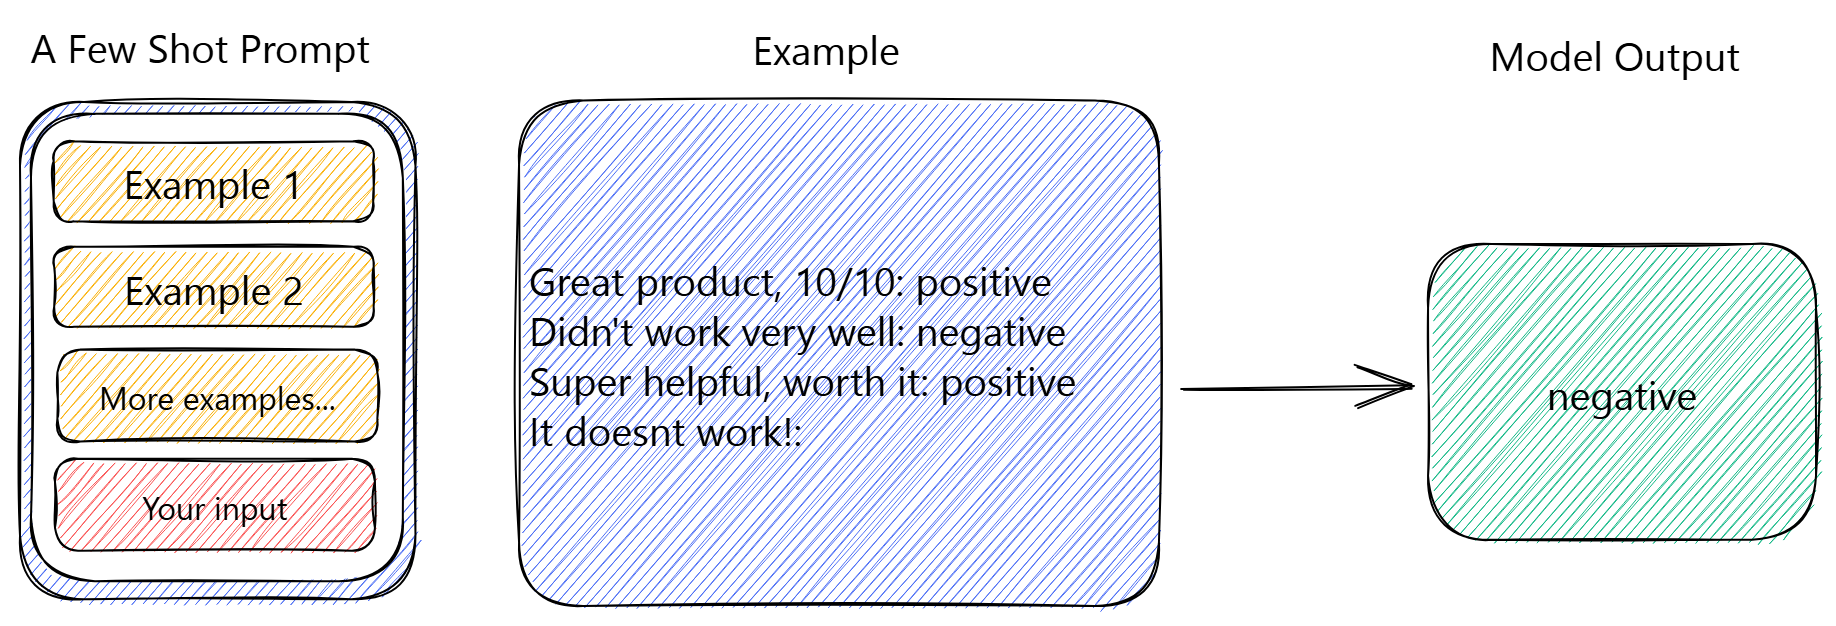

In [ ]:
system_message = """You are an assistant that classifies short user messages into one of three intents:
- \"question\"
- \"command\"
- \"statement\"

Examples:
User: Can you tell me the time?
Intent: question

User: Turn off the lights in the kitchen.
Intent: command

User: It’s getting cold today.
Intent: statement
"""

user_message = """User: Show me my schedule for tomorrow.
Intent:
"""

generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)

### Tactic 6: Specify the steps required to complete a *task*

In [ ]:
text = "In a charming village, siblings Jack and Jill set out on " \
       "a quest to fetch water from a hilltop " \
       "well. As they climbed, singing joyfully, misfortune " \
       "struck—Jack tripped on a stone and tumbled " \
       "down the hill, with Jill following suit. " \
       "Though slightly battered, the pair returned home to " \
       "comforting embraces. Despite the mishap, " \
       "their adventurous spirits remained undimmed, and they " \
       "continued exploring with delight."

system_message = """
Perform the following actions:
1 - Summarize the following text delimited by triple backticks with 1 sentence.
2 - Translate the summary into French.
3 - List each name in the French summary.
4 - Output a json object that contains the following keys: french_summary, num_names.

Separate your answers with line breaks.
"""

user_message = f"""
Text:
```{text}```
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

## Summarization

Summarization can be guided by different contextual or structural constraints depending on the goal. You can ask a model to limit the length of the summary — by words, sentences, or characters — to control verbosity or fit interface requirements. Summarization can also vary by style or audience, for example producing a concise executive brief, a customer-friendly explanation, or a technical abstract. These variations show how prompt design shapes the model’s understanding of what “important” means in context.

### Summarize with a word/sentence/character limit


In [ ]:
prod_review = "Got this panda plush toy for my daughter's birthday, " \
              "who loves it and takes it everywhere. It's soft and " \
              "super cute, and its face has a friendly look. It's " \
              "a bit small for what I paid though. I think there " \
              "might be other options that are bigger for the " \
              "same price. It arrived a day earlier than expected, " \
              "so I got to play with it myself before I gave it to her."

user_message = f"""
Review: ```{prod_review}```
"""

system_message = """
Your task is to generate a short summary of a product review from an ecommerce site.

Summarize the review below, delimited by triple backticks, in at most 30 words.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

### Summarize with a focus on shipping and delivery

In [ ]:
system_message = """
Your task is to generate a short summary of a product review from an ecommerce site to give feedback to the Shipping deparmtment.

Summarize the review below, delimited by triple backticks, in at most 30 words, and focusing on any aspects that mention shipping and delivery of the product.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

### Summarize with a focus on price and value

In [ ]:
system_message = """Your task is to generate a short summary of a product review from an ecommerce site to give feedback to the pricing deparmtment, responsible for determining the price of the product.

Summarize the review below, delimited by triple backticks, in at most 30 words, and focusing on any aspects that are relevant to the price and perceived value.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

### Try "extract" instead of "summarize"

In [ ]:
system_message = """Your task is to extract relevant information from a product review from an ecommerce site to give feedback to the Shipping department.

From the review below, delimited by triple quotes extract the information relevant to shipping and delivery. Limit to 30 words"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

## Inferring Information

Inferring Information involves extracting implicit meaning or attributes from text that are not directly stated but can be deduced from context. In this section, models learn to interpret underlying cues in customer reviews — such as the writer’s emotions, the sentiment of the message, or entities like product names and brands. These and others are very common production use-cases.

### Sentiment (positive/negative)

In [ ]:
lamp_review = "Needed a nice lamp for my bedroom, and this one had " \
              "additional storage and not too high of a price point. " \
              "Got it fast. The string to our lamp broke during the " \
              "transit and the company happily sent over a new one. " \
              "Came within a few days as well. It was easy to put " \
              "together. I had a missing part, so I contacted their " \
              "support and they very quickly got me the missing piece! " \
              "Lumina seems to me to be a great company that cares " \
              "about their customers and products!!"

user_message = f"""
Review: ```{lamp_review}```
"""

system_message = """
What is the sentiment of the following product review, which is delimited with triple backticks?
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

This example explains the need to indicate axact desired LLM output:

In [ ]:
system_message = """
What is the sentiment of the following product review, which is delimited with triple backticks?

Give your answer as a single word, either "positive" or "negative".
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

### Identify emotions

In [ ]:
system_message = """
Identify a list of emotions that the writer of the following review is expressing.
Include no more than five items in the list. Format your answer as a list of lower-case words separated by commas.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

### Extract product and company name from customer reviews

In [ ]:
system_message = """Identify the following items from the review text:
- Item purchased by reviewer
- Company that made the item

The review is delimited with triple backticks.
Format your response as a JSON object with "Item" and "Brand" as the keys.
If the information isn't present, use "unknown" as the value.
Make your response as short as possible.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
print(response)

## News Alert

Infer 5 topics of the given text and throw an alert if the given article is related to NASA.

In [ ]:
story = """
In a recent survey conducted by the government,
public sector employees were asked to rate their level
of satisfaction with the department they work at.
The results revealed that NASA was the most popular
department with a satisfaction rating of 95%.

One NASA employee, John Smith, commented on the findings,
stating, "I'm not surprised that NASA came out on top.
It's a great place to work with amazing people and
incredible opportunities. I'm proud to be a part of
such an innovative organization."

The results were also welcomed by NASA's management team,
with Director Tom Johnson stating, "We are thrilled to
hear that our employees are satisfied with their work at NASA.
We have a talented and dedicated team who work tirelessly
to achieve our goals, and it's fantastic to see that their
hard work is paying off."

The survey also revealed that the
Social Security Administration had the lowest satisfaction
rating, with only 45% of employees indicating they were
satisfied with their job. The government has pledged to
address the concerns raised by employees in the survey and
work towards improving job satisfaction across all departments.
"""

user_message = f"""
Text sample: ```{story}```
"""

In [ ]:
system_message = """
Determine five topics that are being discussed in the following text, which is delimited by triple backticks.
Make each item one or two words long.
Format your response as a list of items separated by commas.
"""

response = generate_outputs(
    system_message=system_message,
    user_message=user_message,
    stream=False
)
topics = response.split(sep=',')
print("Determined Topics: ", topics)

# check if there NASA topic
if 'nasa' in map(lambda s: s.lower().strip(), topics):
    print("ALERT: New NASA story!")

# OPTIMIZATIONS

We have just seen that these models are so flexible and so **good and many differnet** tasks, but, at **what cost**?

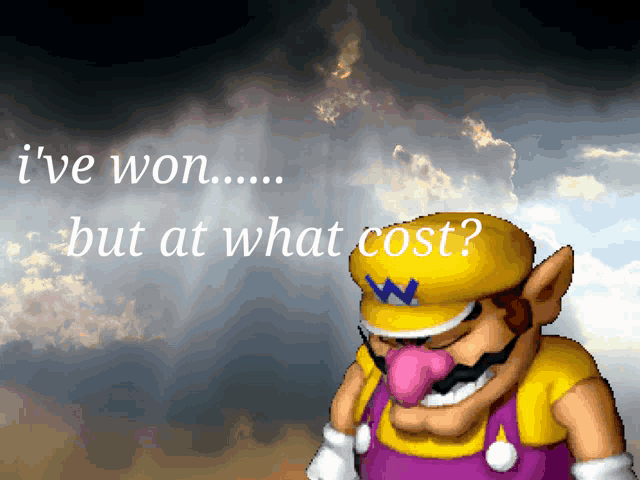

We should be really careful about the tradeoff between:


*   Speed: how many tokens in a certain range of time the model is able to generate (metric: tokens-per-second, tps)
*   Memory size: how much memory is required to run the model (metric: GB)

For sure, the more we spend on the hardware (mainly GPUs) the better we get at both these metrics since larger GPUs have more memory to fit bigger models, and more modern GPU tends to enable a lot more TPS.


But, is there something that we, as NLP experts, can do to overcome these limitations ?

## Memory optimization: quantization

We will use quantization later in this tutorial in order to fine tune bigger models.

HF article: https://huggingface.co/docs/transformers/v4.15.0/performance

BitsAndBytes Lib: https://huggingface.co/docs/bitsandbytes/main/en/index

> Quantization is a technique to reduce the computational and memory costs by representing the weights and activations with low-precision data types like 8-bit integer (int8) instead of the usual 32-bit floating point (float32).

<div>
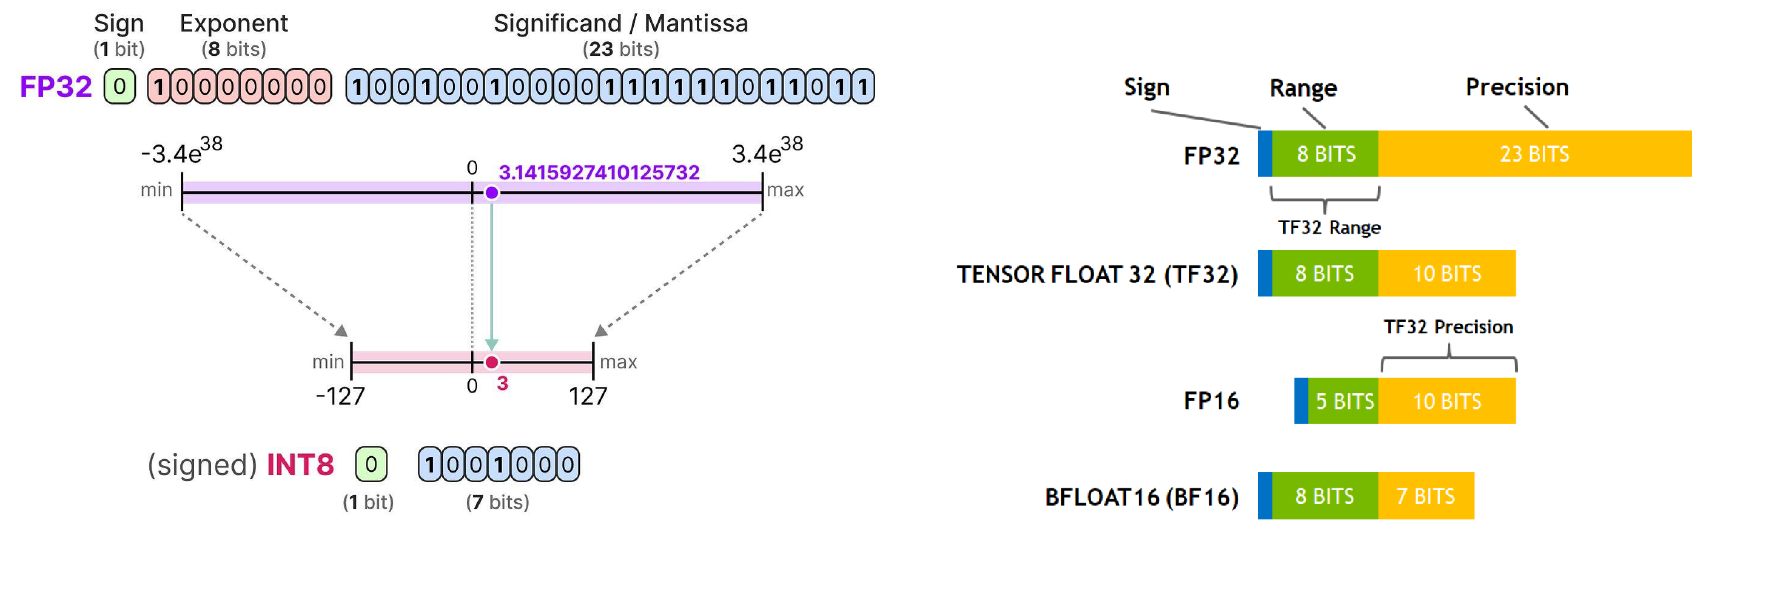

## Memory optimization: Grouped Attention

**Multi-Query Attention**

Fast Transformer Decoding: One Write-Head is All
You Need

https://arxiv.org/pdf/1911.02150

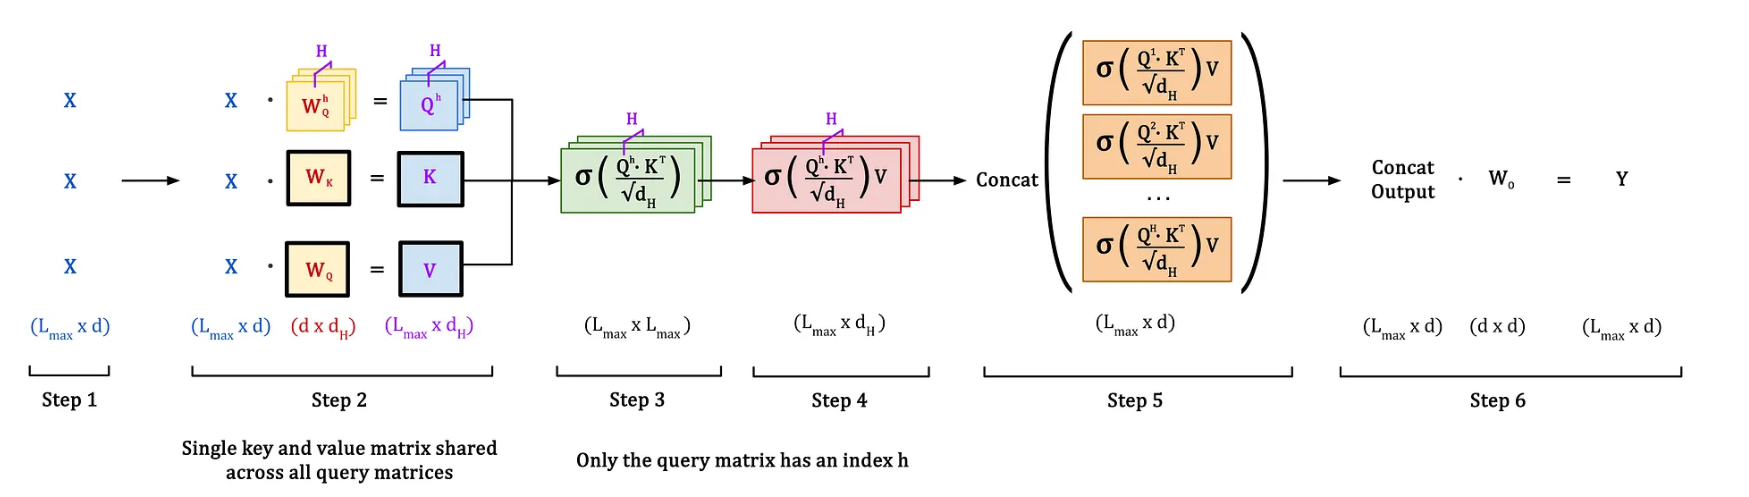

**Grouped Query Attention**

GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints

https://arxiv.org/pdf/2305.13245

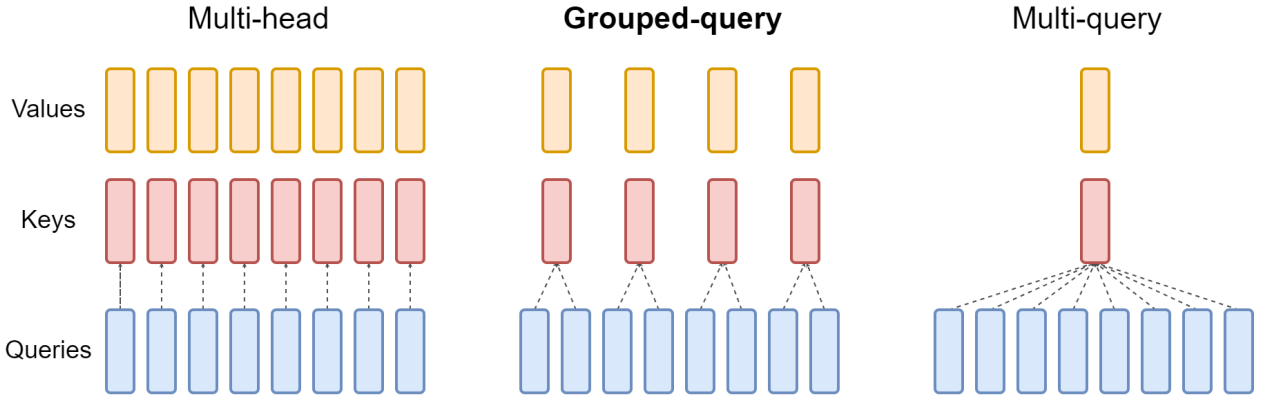

We can see that from the configurations of a model that is implementing GQA or MQA

In [ ]:
from transformers import AutoConfig
config = AutoConfig.from_pretrained("mistralai/Mistral-7B-v0.1")
print(config)
print("SWA window size:", config.sliding_window)
print("Heads (Q / KV):", config.num_attention_heads, "/", config.num_key_value_heads)

Base Mistral config has **SWA 4096**, meaning that for shorter sequences it is equivalent to **standard causal attention**.

For 32 attention heads there are 8 KV heads, meaning that each KV pair has **4 queries in a group**.

## Speed optimization: kv-caching

### KV Cache

HF page with short videos on KV caching: https://huggingface.co/blog/not-lain/kv-caching
> **Key-Value caching** is a technique that helps speed up this process by remembering important information from previous steps. Instead of recomputing everything from scratch, the model reuses what it has already calculated, making text generation much faster and more efficient.

<div>
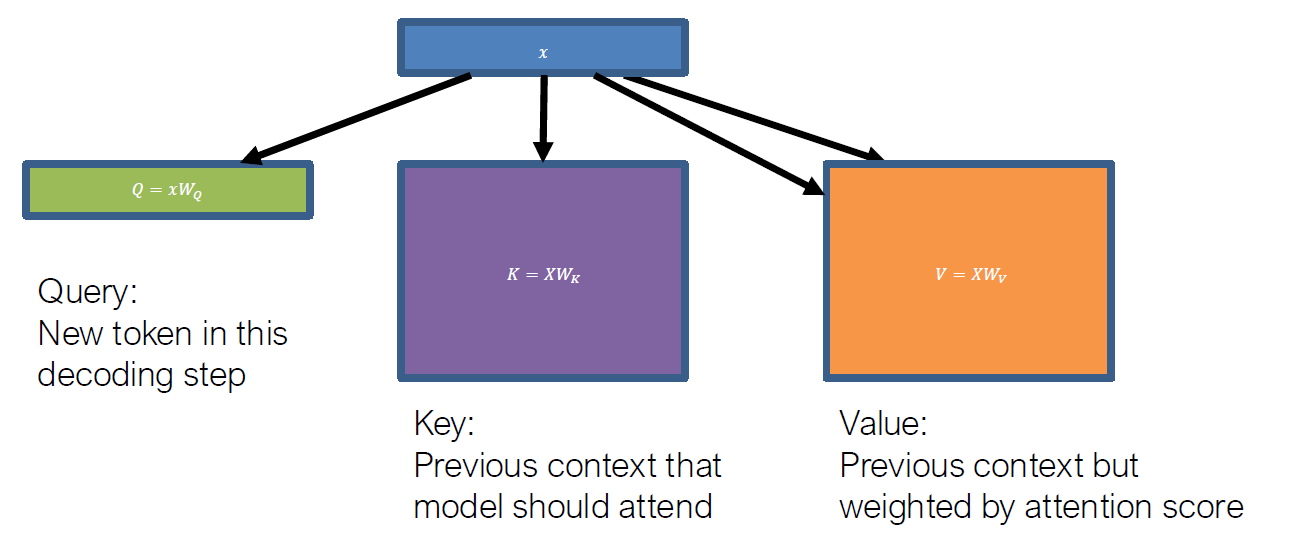
</div>

> For longer context the main memory is occupied not by the model itself, but by the KV cach.

<div>
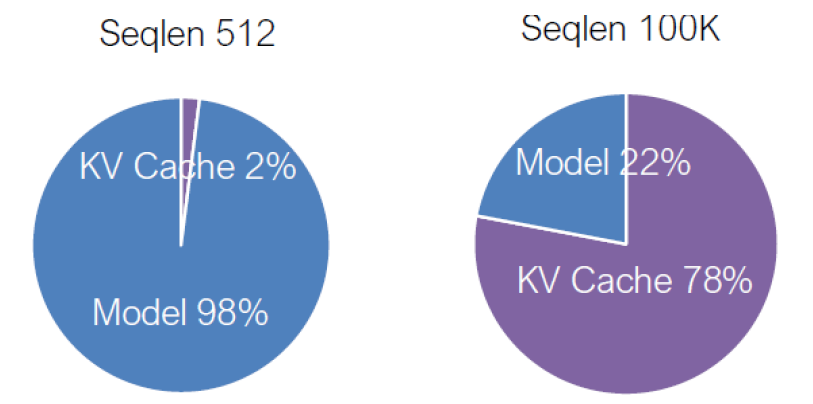
</div>

## Putting it all together

We will now see how these techniques affects the generation process. First of all, we will see the effects of the **kv_caching** and the **MQA**. The **kv_caching** is a mechanism we can enable ro disable during the generation process, whereas the **MQA** (or the Grouped Attention) is a structural difference so we need to have a pretrained model already with such mechanism. For this reason we will see at the beginning an older model form *EleutherAI* called `gpt-neo`. It has 1.3 Billion parameters but the architecture is very close to the original gpt-2. Subsequently, we will compare this model with the newer `llama 3.2` 1 Billion, it has fairly the same size as gpt-neo, but a slightly different architecture with MQA natively implemented.

Let's start by loading  `EleutherAI/gpt-neo-1.3B`

In [ ]:
model_name = "EleutherAI/gpt-neo-1.3B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cuda",
    dtype=torch.float16, # This will load the model in half precision
)

Now we declare the generation configurations:


*   `use_cache`: if `True` enables kv_caching
*   `max_new_tokens`: maximum number of tokens to generate
*   `do_sample`: if `False`, do not make any sample during generation (deterministic outcome)



In [ ]:
from transformers import GenerationConfig

gen_config = GenerationConfig(use_cache= False, max_new_tokens = 100, do_sample=False)

In [ ]:
gen_config

To test how fast a model is able to generate, we need a fairly long context. Let's try to simply **summarize a web page**.

In [ ]:
import urllib.request
import bs4 as bs
import re

# Define a User-Agent to avoid the 403 Forbidden error
url = 'https://en.wikipedia.org/wiki/Pok%C3%A9mon'
req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})

html_doc = urllib.request.urlopen(req).read()
parsed_doc = bs.BeautifulSoup(html_doc, 'lxml')
page = '\n'.join(p.text for p in parsed_doc.find_all('p'))
print(page[:1000]) # Printing the first 1000 characters to verify

Create the prompt with the context, take only the first 200 characters because we don't want to wait long in class, fell free to extend to full context at home!

In [ ]:
prompt = f"Summarize the following document: {page[:2000]}"
input = tokenizer.encode(prompt, return_tensors="pt").to('cuda')
input.shape

Now let's see a baseline generation, no optimizations here:

In [ ]:
import time
start = time.time()
output = model.generate(input, generation_config=gen_config)
end = time.time()

print(f"Runtime: {end - start:.2f} seconds")
print(tokenizer.decode(output[0], skip_special_tokens=True))

Well, it took quite a long time, let's see if enabling the **kv_caching** is speeding up.

In [ ]:
gen_config.use_cache=True

In [ ]:
import time

start = time.time()
output = model.generate(input, generation_config=gen_config)
end = time.time()

print(f"Runtime: {end - start:.2f} seconds")

We managed to speed up the inference! It is roughly 5x faster, wow!

Now we will load a **newer model** with the same number of parameters, to see the effect of **MQA**.

In [ ]:
model_name = "meta-llama/Llama-3.2-1B"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cuda",
    dtype=torch.float16,
    #trust_remote_code=True
)

This is the baseline generation, no kv_caching, only MQA which is active by default since it is part of the architecture of the model.

In [ ]:
import time

gen_config.use_cache=False

start = time.time()
output = model.generate(input, generation_config=gen_config)
end = time.time()

print(f"Runtime: {end - start:.2f} seconds")

With respect to the previous baseline it is a bit faster! Let's see if kv_caching is further improving the speed.

In [ ]:
import time

gen_config.use_cache=True

start = time.time()
output = model.generate(input, generation_config=gen_config)
end = time.time()

print(f"Runtime: {end - start:.2f} seconds")

The speed up with **MQA + kv_caching** is not that much compared to **kv_caching** alone, can you tell why?

# Fine-Tuning for SQL query generation

In this section we are going to use an example presented on AMLD 2025 workshop in Lausanne by people from EPFL and HuggingFace.

In [1]:
!pip install -U bitsandbytes transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 65.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [2]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig , TrainingArguments, pipeline, AutoConfig
from tqdm import tqdm

## Use Case

##### We aim to finetune a language model specifically designed to interpret and convert natural language instructions into SQL queries. This initiative seeks to streamline the data retrieval process, making it more accessible and user-friendly for non-technical users. By simplifying the query generation process, we can significantly reduce the time and expertise required to extract valuable insights from databases.
##### The advantage of using a small model is to create a seamless and fast bridge between natural language and database languages without leaking our data schema to third parties.

## Dataset Selection/Creation

HF dataset: https://huggingface.co/datasets/b-mc2/sql-create-context

There are 78,577 examples of natural language queries, SQL CREATE TABLE statements, and SQL Query answering the question using the CREATE statement as context. This dataset was built with text-to-sql LLMs in mind, intending to prevent hallucination of column and table names often seen when trained on text-to-sql datasets. We are going to split into train and test, and then test on subsample of 100 examples for faster evaluation.

In [3]:
dataset = load_dataset("b-mc2/sql-create-context", split="train")
train_test_split = dataset.train_test_split(test_size=0.2)
train_dataset = train_test_split['train']
test_dataset = train_test_split['test']
train_dataset, test_dataset

(Dataset({
     features: ['answer', 'question', 'context'],
     num_rows: 62861
 }),
 Dataset({
     features: ['answer', 'question', 'context'],
     num_rows: 15716
 }))

In [4]:
train_dataset[1]

{'answer': 'SELECT d_50 FROM table_name_65 WHERE d_41 = "d 41"',
 'question': 'What is the D 50 when the D 41 is d 41?',
 'context': 'CREATE TABLE table_name_65 (d_50 VARCHAR, d_41 VARCHAR)'}

## Mistral 7B

We are going to use `mistralai/Mistral-7B-Instruct-v0.2`.

Mistral is a 7B parameter language model, available as a pretrained and instruction-tuned variant, focused on balancing the scaling costs of large models with performance and efficient inference.

Architecture details:
- Sliding Window Attention (SWA)  
- Grouped-query attention (GQA)
- BPE tokenizer

HF model: https://huggingface.co/mistralai/Mistral-7B-Instruct-v0.2

HF Mistral page: https://huggingface.co/docs/transformers/en/model_doc/mistral

Original Page: https://mistral.ai/news/announcing-mistral-7b



In [5]:
config = AutoConfig.from_pretrained("mistralai/Mistral-7B-v0.1")
print(config)
print("SWA window size:", config.sliding_window)
print("Heads (Q / KV):", config.num_attention_heads, "/", config.num_key_value_heads)

MistralConfig {
  "architectures": [
    "MistralForCausalLM"
  ],
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "dtype": "bfloat16",
  "eos_token_id": 2,
  "head_dim": 128,
  "hidden_act": "silu",
  "hidden_size": 4096,
  "initializer_range": 0.02,
  "intermediate_size": 14336,
  "max_position_embeddings": 32768,
  "model_type": "mistral",
  "num_attention_heads": 32,
  "num_hidden_layers": 32,
  "num_key_value_heads": 8,
  "pad_token_id": null,
  "rms_norm_eps": 1e-05,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "sliding_window": 4096,
  "tie_word_embeddings": false,
  "transformers_version": "5.7.0",
  "use_cache": true,
  "vocab_size": 32000
}

SWA window size: 4096
Heads (Q / KV): 32 / 8


Base Mistral config has **SWA 4096**, meaning that for shorter sequences it is equivalent to **standard causal attention**.

For 32 attention heads there are 8 KV heads, meaning that each KV pair has **4 queries in a group**.

In [6]:
name_or_path = "mistralai/Mistral-7B-Instruct-v0.2"

# model = AutoModelForCausalLM.from_pretrained(
#     name_or_path,
#     device_map="auto",
#     dtype=torch.bfloat16
# )

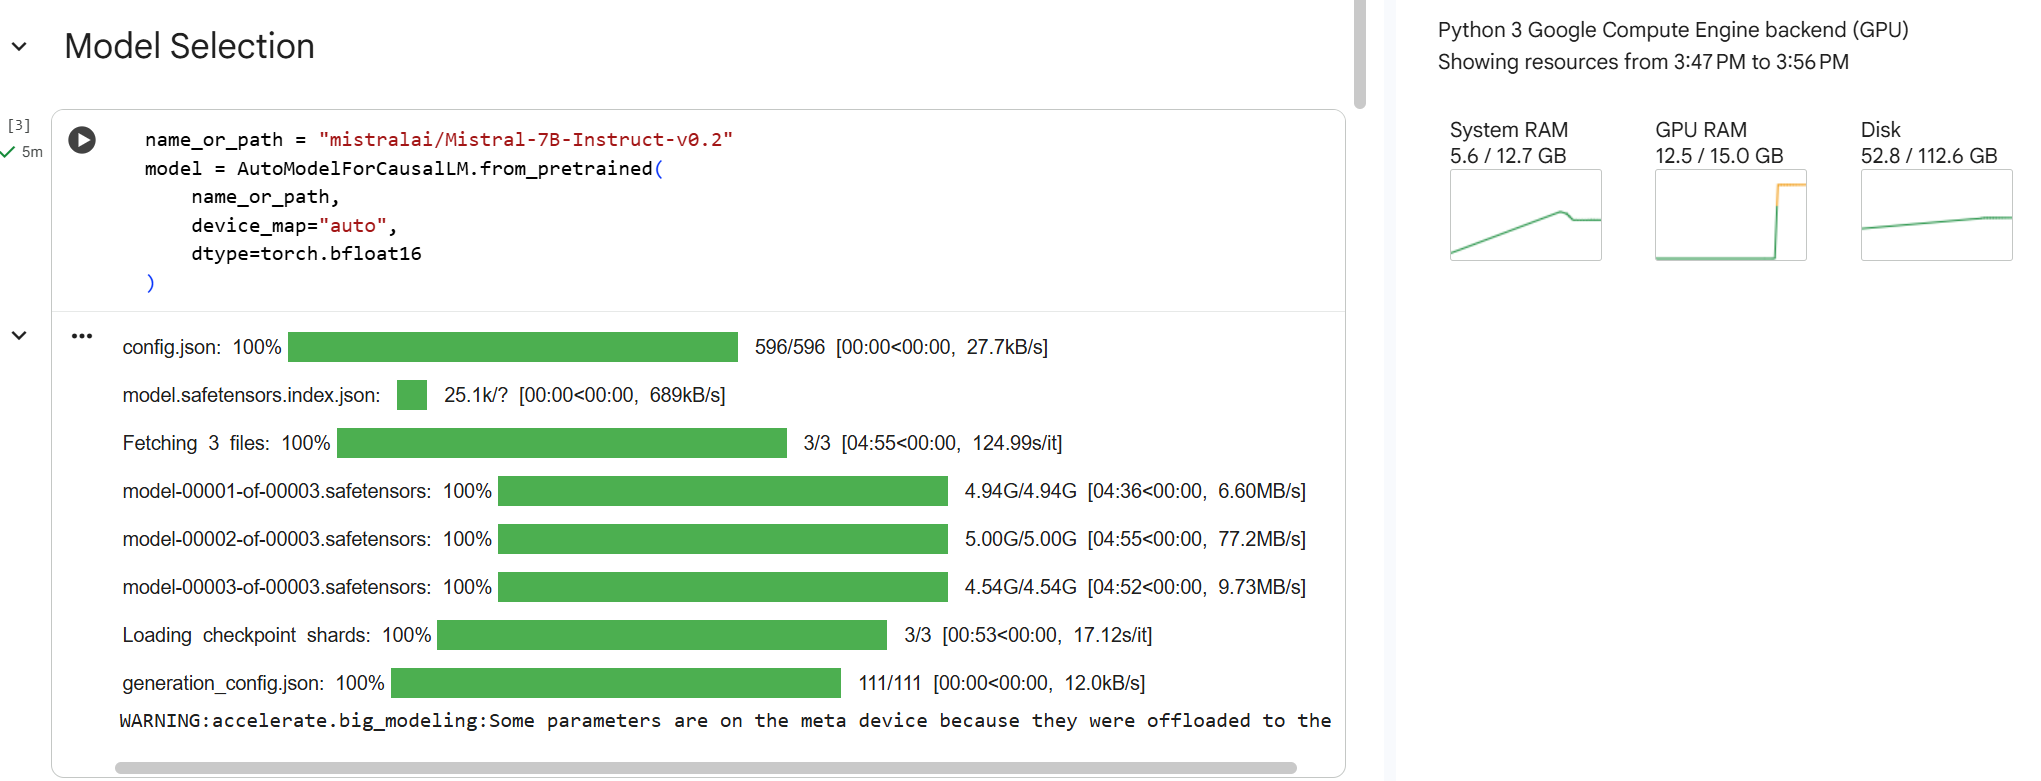

If we load full model from HF, we get 12.5 GB VRAM, that is arleady almost fits Colab limits, and there is no space for model fine-tuning.

That's why we are going to use **quntization together with parameter-efficient fine-tuning**.

## Load Quantized Model

Let's first load the quantized model to see the VRAM change, then have a look at what quantization actually is.

In [7]:
def load_tokenizer(name_or_path):
    tokenizer = AutoTokenizer.from_pretrained(name_or_path)
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'left'
    return tokenizer

def create_bnb_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16
    )

def generate_outputs(prompts, model, tokenizer):
    pipe = pipeline(
        "text-generation",
        model=model,
        tokenizer=tokenizer,
        device_map="auto",
        return_full_text=False
    )
    outputs = pipe(
        prompts,
        batch_size=8,
        max_new_tokens=256,
        do_sample=True,
        temperature=0.7,
        top_k=50,
        top_p=0.95,
        eos_token_id=pipe.tokenizer.eos_token_id,
        pad_token_id=pipe.tokenizer.pad_token_id
    )
    return outputs

In [8]:
name_or_path = "mistralai/Mistral-7B-Instruct-v0.2"

# create tokenizer
tokenizer = load_tokenizer(name_or_path)

# Prepare Quantization Configuration
bnb_config = create_bnb_config()

# Load model with quantization configuration
model = AutoModelForCausalLM.from_pretrained(
    name_or_path,
    device_map="auto",
    dtype=torch.bfloat16,
    quantization_config=bnb_config
)

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

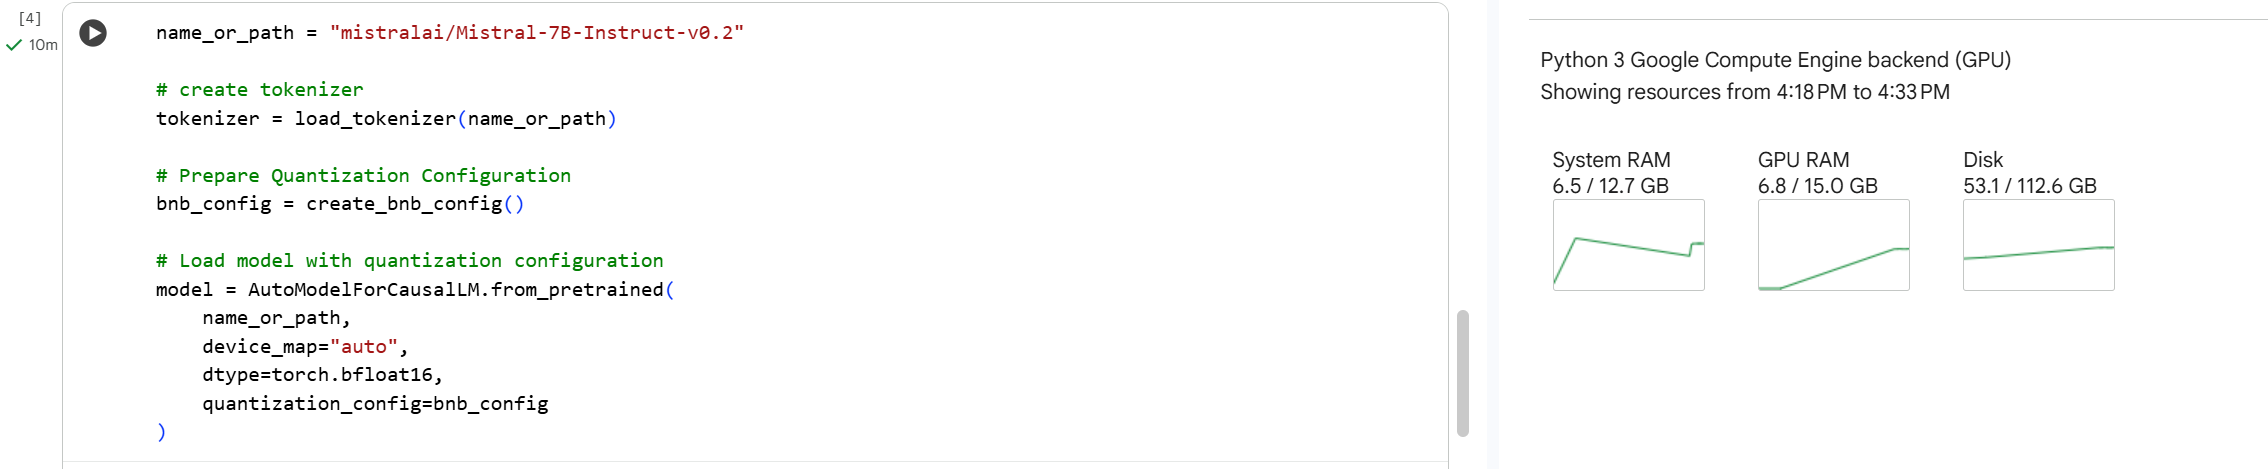

Good, now we have 6.8 GB VRAM, that is almost twice less than the full model and we have some space for model fine-tuning.

## Chat Formatting
Here we format the training data in a conversation using chat template.

In [9]:
system_message = """You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.
SCHEMA:
{schema}"""

In [10]:
def create_conversation(sample):
  chat =[
      {"role": "user", "content": system_message.format(schema=sample["context"]) + "\n\n" + sample["question"]},
      {"role": "assistant", "content": sample["answer"]}
    ]

  return {'conversation' : tokenizer.apply_chat_template(chat, tokenize=False)}

In [11]:
train_dataset_formatted = train_dataset.map(create_conversation)
test_dataset_formatted = test_dataset.map(create_conversation)

Map:   0%|          | 0/62861 [00:00<?, ? examples/s]

Map:   0%|          | 0/15716 [00:00<?, ? examples/s]

In [12]:
train_dataset_formatted[0]

{'answer': 'SELECT tries_against FROM table_13564702_4 WHERE tries_for = "62"',
 'question': 'How many tries against got the club with 62 tries for?',
 'context': 'CREATE TABLE table_13564702_4 (tries_against VARCHAR, tries_for VARCHAR)',
 'conversation': '<s> [INST] You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.\nSCHEMA:\nCREATE TABLE table_13564702_4 (tries_against VARCHAR, tries_for VARCHAR)\n\nHow many tries against got the club with 62 tries for? [/INST] SELECT tries_against FROM table_13564702_4 WHERE tries_for = "62"</s>'}

In [13]:
print(train_dataset_formatted[0]['conversation'])

<s> [INST] You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.
SCHEMA:
CREATE TABLE table_13564702_4 (tries_against VARCHAR, tries_for VARCHAR)

How many tries against got the club with 62 tries for? [/INST] SELECT tries_against FROM table_13564702_4 WHERE tries_for = "62"</s>


## Initial Model Evaluation (Before Finetuning)

Check what is the initial nodel evaluation before training in terms of exact string match accuracy. We'll take evaluation subset of 100 samples. Evaluation takes some time...

In [14]:
def get_prompt(conversation: str) -> str:
    return conversation.split('[/INST]')[0] + '[/INST]'

In [15]:
number_of_eval_samples = 100
eval_subset = test_dataset_formatted.shuffle(seed=0).select(range(number_of_eval_samples))
prompts = [get_prompt(x["conversation"]) for x in eval_subset]
outputs = generate_outputs(prompts, model, tokenizer)

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens', 'temperature', 'top_k', 'eos_token_id', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True 

How do generated SQL queries look like?

In [16]:
for i in range(3):
    prompt = prompts[i]
    predicted_answer = outputs[i][0]["generated_text"]
    label = eval_subset[i]["answer"]
    print('=' * 80)
    print("Prompt: " + prompt)
    print('-' * 80)
    print("Predicted Answer: " + predicted_answer)
    print('-' * 80)
    print("Label           : " + label)

Prompt: <s> [INST] You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.
SCHEMA:
CREATE TABLE table_name_52 (longitude VARCHAR, latitude VARCHAR)

If the latitude is 76°25′n, what is the longitude? [/INST]
--------------------------------------------------------------------------------
Predicted Answer:  To find the longitude based on the given latitude value, we need additional information such as the Prime Meridian used for the given latitude (Northern or Southern Hemisphere) and the conversion factor to transform degrees, minutes, and seconds to decimal degrees. However, the provided latitude value "76°25′n" is not sufficient to generate an accurate SQL query.

Assuming we have a separate table containing this conversion information, the SQL query would look like this:

```sql
SELECT longitude
FROM latitude_conversion_table
WHERE latitude = '76°25′n'
AND hemisphere = 'N' -- Northern Hemisphere

In [17]:
preds = [o[0]["generated_text"].strip() for o in outputs]
labels = [x["answer"] for x in eval_subset]

# exact-match accuracy (adjust if your labels need normalization)
acc = sum(p == y for p, y in zip(preds, labels)) / len(labels)
print(f"Accuracy: {acc*100 :.2f}%")

Accuracy: 0.00%


We see that accuracy is 0 (none of the generated texts match exactly the real query). Generated responses contain extra text and lack of accurate query strings. We will train a model to learn the desired outputs.

## Qlora Training

We are going to use TRL - Transformer Reinforcement Learning library that provides a set of tools to train transformer language models with methods like **Supervised Fine-Tuning (SFT)**, Direct Preference Optimization (DPO) or Reward Modeling.

TRL: https://pypi.org/project/trl/0.3.1/

SFT: https://huggingface.co/docs/trl/v0.25.0/en/sft_trainer#trl.SFTTrainer

SFT Config: https://huggingface.co/docs/trl/v0.25.0/en/sft_trainer#trl.SFTConfig

### Parameter-Efficient Fine-Tuning (PEFT)

PEFT methods only fine-tune a small number of (extra) model parameters - significantly decreasing computational and storage costs - while yielding performance comparable to a fully fine-tuned model. We are going to use LoRA - one of PEFT methods.

> **LoRA (Low-Rank Adaptation)** is a popular and lightweight training technique that significantly reduces the number of trainable parameters. It works by inserting a smaller number of new weights into the model layers and only these are trained.

> LoRA parameterss are `trainable`, the base quantized weights are `frozen`.

Sinse the model weights are quantized, LoRA adaper becomes **Quantized LoRA** and leads to even more memory-efficient training.

LoRA Paper: https://arxiv.org/abs/2106.09685

Qlora Paper: https://arxiv.org/abs/2305.14314

$$
h = Wx
$$

$$
h = (W + AB) x
$$

<div>
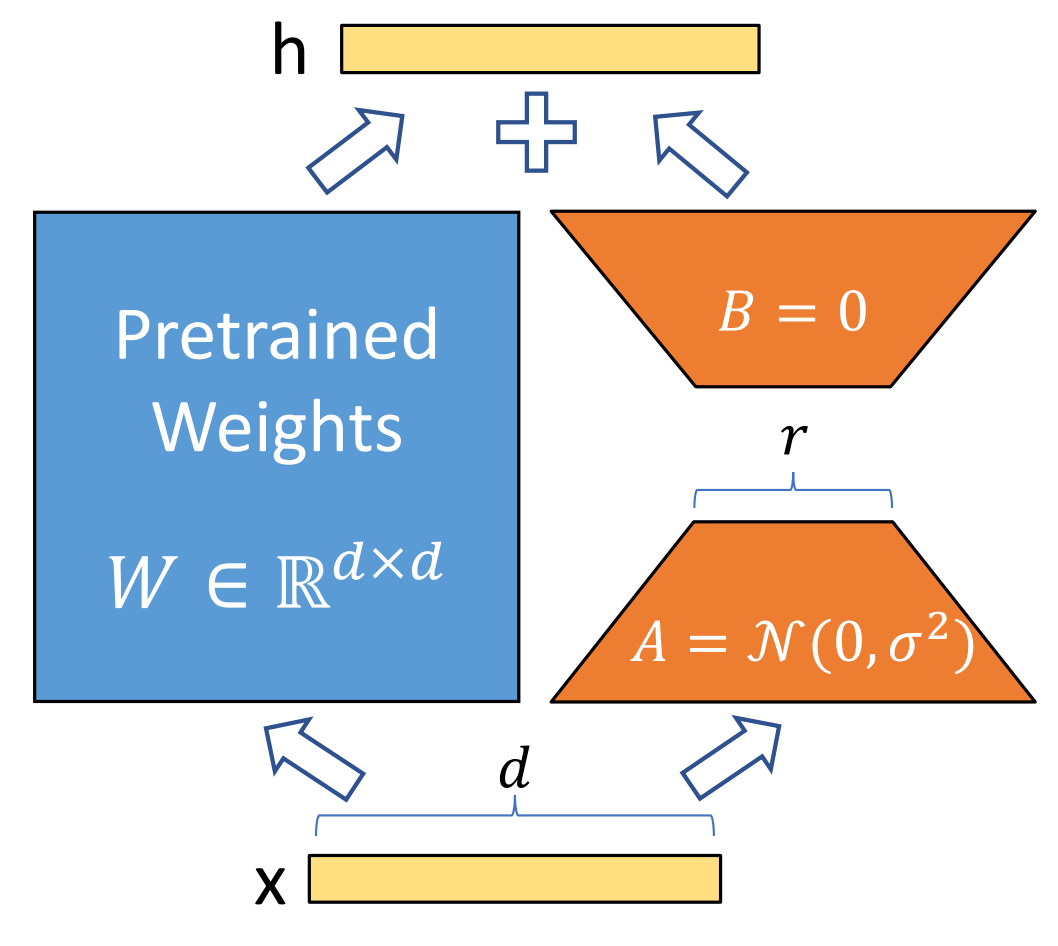

### Load LoRA configuration and set up SFT trainer from TRL library

In [ ]:
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

In [ ]:
lora_config = LoraConfig(
    r=16,                                   # LoRA rank (reduced dimension)
    target_modules="all-linear",            # Apply lora adapter only to linear layers
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    task_type="CAUSAL_LM",
)

args = SFTConfig(
    output_dir="Mistral-for-sql",           # directory to save and repository id
    max_length=128,                         # max sequence length for model input (tokens)
    packing=False,                          # set to True when Flash Attention is installed
    dataset_text_field="conversation",
    dataset_kwargs={
        "add_special_tokens": False,       # We template with special tokens
        "append_concat_token": False,      # No need to add additional separator token
    },

    num_train_epochs=0.05,                  # number of training epochs
    per_device_train_batch_size=50,         # batch size per device during training
    #gradient_accumulation_steps=2,         # number of steps before performing a backward/update pass
    gradient_checkpointing=True,            # use gradient checkpointing to save memory
    optim="adamw_torch_fused",              # use fused adamw optimizer
    logging_steps=10,                       # log every 10 steps
    save_strategy="epoch",                  # save checkpoint every epoch
    learning_rate=2e-4,                     # learning rate, based on QLoRA paper
    max_grad_norm=0.3,                      # max gradient norm based on QLoRA paper
    warmup_ratio=0.03,                      # warmup ratio based on QLoRA paper
    lr_scheduler_type="constant"            # use constant learning rate scheduler
)

trainer = SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    train_dataset=train_dataset_formatted,
    peft_config=lora_config,
)

Adding EOS to train dataset:   0%|          | 0/62861 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/62861 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/62861 [00:00<?, ? examples/s]

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.
/opt/conda/envs/pytorch/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1044: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss
10,1.562300
20,0.808800
30,0.673100
40,0.585500
50,0.552200
60,0.542700


TrainOutput(global_step=63, training_loss=0.776622041823372, metrics={'train_runtime': 761.3546, 'train_samples_per_second': 4.128, 'train_steps_per_second': 0.083, 'total_flos': 1.73035775066112e+16, 'train_loss': 0.776622041823372, 'entropy': 0.5858545899391174, 'num_tokens': 361034.0, 'mean_token_accuracy': 0.8577906886736552, 'epoch': 0.050079491255961846})

Trainer reports the average loss over all optimization steps seen so far — i.e. the epoch-level mean.
It’s not the last minibatch loss that we see in logs, that's why it is different. Now we can change how does the model perform on test data.

## Testing and Evaluation of Finetuned Model

To test the model, we need no load the model itself and trained adapter weights. We are going tp use `AutoPeftModelForCausalLM` class for that with specification with the last checkpoint directory.

In [ ]:
import os, glob, torch, json
from transformers import AutoTokenizer, pipeline, BitsAndBytesConfig
from peft import AutoPeftModelForCausalLM

In [ ]:
# pick the last checkpoint
output_dir = "Mistral-for-sql"
ckpts = sorted(glob.glob(os.path.join(output_dir, "checkpoint-*")), key=os.path.getmtime)
ckpt_dir = ckpts[-1] if ckpts else output_dir
with open(ckpt_dir + "/adapter_config.json", "r") as f:
    bnb_dict = json.loads(f.read())

# load tokenizer
ckpt_tokenizer = AutoTokenizer.from_pretrained(ckpt_dir)

# Create the same quantization config
bnb_config = BitsAndBytesConfig(**bnb_dict)

ckpt_model = AutoPeftModelForCausalLM.from_pretrained(
    ckpt_dir,
    device_map="auto",
    dtype=torch.bfloat16,
    quantization_config=bnb_config,
)

ckpt_model.eval()

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): MistralForCausalLM(
      (model): MistralModel(
        (embed_tokens): Embedding(32000, 4096)
        (layers): ModuleList(
          (0-31): 32 x MistralDecoderLayer(
            (self_attn): MistralAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear4bit(

In [ ]:
outputs = generate_outputs(prompts, ckpt_model, ckpt_tokenizer)

preds = [o[0]["generated_text"].strip() for o in outputs]
labels = [x["answer"] for x in eval_subset]

# exact-match accuracy (adjust if your labels need normalization)
acc = sum(p == y for p, y in zip(preds, labels)) / len(labels)
print(f"Accuracy: {acc*100 :.2f}%")

Device set to use cuda:0


Accuracy: 68.00%


Great, now we have 68% accuracy that is much better than intial 0%. Note, that we've done only 0.05 epoch.

Let's see the ouputs:

In [ ]:
for i in range(3):
    prompt = prompts[i]
    predicted_answer = outputs[i][0]["generated_text"]
    label = eval_subset[i]["answer"]
    print('=' * 80)
    print("Prompt: " + prompt)
    print('-' * 80)
    print("Predicted Answer: " + predicted_answer.strip())
    print('-' * 80)
    print("Label           : " + label + '\n')

Prompt: <s> [INST] You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.
SCHEMA:
CREATE TABLE table_197446_1 (office VARCHAR, term_ended VARCHAR)

What group was in office when the term ended in January 3, 1993? [/INST]
--------------------------------------------------------------------------------
Predicted Answer: SELECT office FROM table_197446_1 WHERE term_ended = "January 3, 1993"
--------------------------------------------------------------------------------
Label           : SELECT office FROM table_197446_1 WHERE term_ended = "January 3, 1993"

Prompt: <s> [INST] You are an text to SQL query translator. Users will ask you questions in English and you will generate a SQL query based on the provided SCHEMA.
SCHEMA:
CREATE TABLE table_1965650_10 (player VARCHAR, nhl_team VARCHAR)

What player is from the California Golden Seals? [/INST]
-----------------------------------------------------

# Finetuing for Math Reasoning

We will use `usloth` library for faster and efficient LLM training. The main advantage is gained when you have installed `Flash Attention`. It is not the case for this notebook and it is a bit tricky in terms of environment, but once set, it is very helpful. We use `xformers` as alternative.

Unsloth: https://docs.unsloth.ai/

Flash Attention: https://pypi.org/project/flash-attn/0.2.4/

We are going to represent the example from unsloth for math reasoning finetuning:

Notebook: https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Qwen3_(4B)-Thinking.ipynb#scrollTo=bv-1hctMPUmr

HF dataset: https://huggingface.co/datasets/unsloth/OpenMathReasoning-mini

Install packages as adviced in the original notebook:

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9\.]{3,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.32.post2" if v == "2.8.0" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets>=3.4.1,<4.0.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
from unsloth import FastLanguageModel
from unsloth.chat_templates import get_chat_template, train_on_responses_only

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [ ]:
from datasets import load_dataset
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig , TrainingArguments, pipeline, TextStreamer
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig
from tqdm import tqdm

## Load the model from `unsloth` repo

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/Qwen3-4B-Thinking-2507",
    max_seq_length = 2048,
    load_in_4bit = True                         # 4 bit quantization to reduce memory
)

==((====))==  Unsloth 2025.11.2: Fast Qwen3 patching. Transformers: 4.56.2.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.32.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/238 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

We now add LoRA adapters so we only need to update a small amount of parameters. Also, we use `get_chat_template` function form unsloth to apply the correct chat template to tokenizer.

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 32,                                     # Choose any number > 0 ! Suggested 8, 16, 32, 64, 128
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 32,
    lora_dropout = 0,                           # Supports any, but = 0 is optimized
    bias = "none",                              # Supports any, but = "none" is optimized
    # [NEW] "unsloth" uses 30% less VRAM, fits 2x larger batch sizes!
    use_gradient_checkpointing = "unsloth",     # True or "unsloth" for very long context
    random_state = 3407
)
tokenizer = get_chat_template(tokenizer, chat_template = "qwen3-thinking")

Unsloth 2025.11.2 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## Format Dataset

We now use the `Qwen-3` format for conversation style finetunes. We sample 10% of verifiable reasoning traces that used DeepSeek R1, and whicht got > 95% accuracy. Qwen-3 renders multi turn conversations like below:

```
<|im_start|>user
Hello!<|im_end|>
<|im_start|>assistant
Hey there!<|im_end|>
```

In [ ]:
def generate_conversation(examples):
    problems  = examples["problem"]
    solutions = examples["generated_solution"]
    conversations = []
    for problem, solution in zip(problems, solutions):
        conversations.append([
            {"role" : "user",      "content" : problem},
            {"role" : "assistant", "content" : solution},
        ])
    texts = [
        tokenizer.apply_chat_template(convo, tokenize=False, add_generation_prompt=False)
        for convo in conversations
    ]
    return { "conversations": conversations, "text": texts}

In [ ]:
dataset = load_dataset("unsloth/OpenMathReasoning-mini", split = "cot")
dataset = dataset.map(generate_conversation, batched = True)
dataset

README.md:   0%|          | 0.00/603 [00:00<?, ?B/s]

data/cot-00000-of-00001.parquet:   0%|          | 0.00/106M [00:00<?, ?B/s]

Generating cot split:   0%|          | 0/19252 [00:00<?, ? examples/s]

Map:   0%|          | 0/19252 [00:00<?, ? examples/s]

Dataset({
    features: ['expected_answer', 'problem_type', 'problem_source', 'generation_model', 'pass_rate_72b_tir', 'problem', 'generated_solution', 'inference_mode', 'conversations', 'text'],
    num_rows: 19252
})

In [ ]:
print("Problem: ", dataset[100]['problem'])
print("Solution: ", dataset[100]['generated_solution'])
print("Expected Answer: ", dataset[100]['expected_answer'])

Problem:  On a wall, there are two clocks with the same shape (radius) and the same speed, but they may not show the same hour. The minimum distance between the edges of their hands is \( m \), and the maximum distance is \( M \). What is the distance between their centers?
Solution:  <think>
Okay, so I have this problem here about two clocks on a wall. Both clocks have the same radius and the same speed, but they might show different times. The minimum distance between the edges of their hands is m, and the maximum is M. I need to find the distance between their centers. Hmm, let's break this down.

First, let me visualize the situation. Both clocks are circular with the same radius, let's say radius r. The hands of each clock are moving at the same speed, so their minute and hour hands move at the same rates. However, they might not be showing the same time, which means their hands could be pointing in different directions. The edges of their hands—so the tips of the hands—are what w

In [ ]:
dataset[100]['text']

'<|im_start|>user\nOn a wall, there are two clocks with the same shape (radius) and the same speed, but they may not show the same hour. The minimum distance between the edges of their hands is \\( m \\), and the maximum distance is \\( M \\). What is the distance between their centers?<|im_end|>\n<|im_start|>assistant\n<think>\nOkay, so I have this problem here about two clocks on a wall. Both clocks have the same radius and the same speed, but they might show different times. The minimum distance between the edges of their hands is m, and the maximum is M. I need to find the distance between their centers. Hmm, let\'s break this down.\n\nFirst, let me visualize the situation. Both clocks are circular with the same radius, let\'s say radius r. The hands of each clock are moving at the same speed, so their minute and hour hands move at the same rates. However, they might not be showing the same time, which means their hands could be pointing in different directions. The edges of their 

## Funetuning

Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`.

In [ ]:
args = SFTConfig(
    dataset_text_field = "text",           # dataset field
    per_device_train_batch_size = 2,
    gradient_accumulation_steps = 4,       # Use GA to mimic batch size
    warmup_steps = 5,
    # num_train_epochs = 1,                # Set this for 1 full training run.
    max_steps = 60,
    learning_rate = 2e-4,                  # Reduce to 2e-5 for long training runs
    logging_steps = 1,
    optim = "adamw_8bit",
    weight_decay = 0.001,
    lr_scheduler_type = "linear",
    seed = 3407,
    report_to = "none",
)

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    eval_dataset = None, # Can set up evaluation!
    args = args
)

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/19252 [00:00<?, ? examples/s]

We also use Unsloth's `train_on_completions` method to only train on the assistant outputs and ignore the loss on the user's inputs. This helps increase accuracy of finetuning.

In [ ]:
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<|im_start|>user\n",
    response_part = "<|im_start|>assistant\n",
)

Map (num_proc=6):   0%|          | 0/19252 [00:00<?, ? examples/s]

Let's verify masking the instruction part is done:

In [ ]:
tokenizer.decode(trainer.train_dataset[100]["input_ids"])[:700]

"<|im_start|>user\nOn a wall, there are two clocks with the same shape (radius) and the same speed, but they may not show the same hour. The minimum distance between the edges of their hands is \\( m \\), and the maximum distance is \\( M \\). What is the distance between their centers?<|im_end|>\n<|im_start|>assistant\n<think>\nOkay, so I have this problem here about two clocks on a wall. Both clocks have the same radius and the same speed, but they might show different times. The minimum distance between the edges of their hands is m, and the maximum is M. I need to find the distance between their centers. Hmm, let's break this down.\n\nFirst, let me visualize the situation. Both clocks are circular "

Now let's print the masked out example - you should see only the answer is present:

In [ ]:
tokenizer.decode([
    tokenizer.pad_token_id if x == -100 else x
    for x in trainer.train_dataset[100]["labels"]
]).replace(tokenizer.pad_token, " ")[:400]

"                                                                    <think>\nOkay, so I have this problem here about two clocks on a wall. Both clocks have the same radius and the same speed, but they might show different times. The minimum distance between the edges of their hands is m, and the maximum is M. I need to find the distance between their centers. Hmm, let's break this down.\n\nFirst, let"

## Train the model

Show current memory stats

In [ ]:
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.741 GB.
3.816 GB of memory reserved.


In [ ]:
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,252 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 66,060,288 of 4,088,528,384 (1.62% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.588400
2,0.519400
3,0.613400
4,0.538500
5,0.499700
6,0.443900
7,0.364800
8,0.385500
9,0.471200
10,0.422700


Show final memory and time stats

In [ ]:
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1541.2579 seconds used for training.
25.69 minutes used for training.
Peak reserved memory = 7.699 GB.
Peak reserved memory for training = 3.883 GB.
Peak reserved memory % of max memory = 52.228 %.
Peak reserved memory for training % of max memory = 26.341 %.


### Inference
Let's run the model via Unsloth native inference! According to the `Qwen-3` team, the recommended settings for instruct inference are `temperature = 0.7, top_p = 0.8, top_k = 20`

For reasoning chat based inference, `temperature = 0.6, top_p = 0.95, top_k = 20`

In [ ]:
messages = [
    {"role" : "user", "content" : "Solve (x + 2)^2 = 0."}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize = False,
    add_generation_prompt = True, # Must add for generation
    enable_thinking = False, # Disable thinking
)

response = model.generate(
    **tokenizer(text, return_tensors = "pt").to("cuda"),
    max_new_tokens = 840, # Increase for longer outputs!
    temperature = 0.7, top_p = 0.8, top_k = 20, # For non thinking
    streamer = TextStreamer(tokenizer, skip_prompt = False),
)

<|im_start|>user
Solve (x + 2)^2 = 0.<|im_end|>
<|im_start|>assistant
<think>
Okay, let's see. I need to solve the equation (x + 2)^2 = 0. Hmm, so first, I remember that when you have something squared equals zero, the only solution is when the base is zero. Because if you square any non-zero number, it becomes positive, right? So, if (x + 2)^2 is zero, then x + 2 must be zero. That makes sense. 

So, I can set x + 2 equal to zero and solve for x. Let me write that down. 

Starting with the equation:
(x + 2)^2 = 0

Take the square root of both sides. But wait, since it's a square, the square root of 0 is 0. So, that gives me:
x + 2 = 0

Then, subtract 2 from both sides:
x = -2

But wait, is that the only solution? Since squaring can sometimes introduce extraneous solutions, but in this case, because we're setting the square equal to zero, the only solution is x = -2. Let me check by plugging it back in. 

If x is -2, then (x + 2) is (-2 + 2) = 0. Squaring that gives 0^2 = 0, which matc